# Benchmark: Reproducing SI WIMP limits from XENONnT & LZ

In [1]:
import os
import diamx
from diamx.model import DiamxModel
from diamx.utils import generate_bin_array
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

diamx_dir = os.path.dirname(diamx.__file__)

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="appletree.config")
warnings.filterwarnings("ignore", category=UserWarning, module="appletree.component")

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform
Using aptext package from https://github.com/XENONnT/applefiles


2025-09-10 04:03:49.576383: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.4.131). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## 0. Generate Input WIMP spectrum

Using package wimprates

In [2]:
import wimprates

energies = np.linspace(0.01, 100, 200)
wimp_masses = (
    list(range(6, 130, 2)) + list(range(130, 400, 10)) + [400, 500, 600, 800, 1000]
)
wimp_masses += list(range(100, 1000, 50)) + [1000, 2500, 5000, 10000]
wimp_masses = set(wimp_masses)
spectrum_data = np.zeros((len(energies), 2))
spectrum_data[:, 0] = energies
os.makedirs("./diamx_output/spectrum", exist_ok=True)
for wimp_mass in wimp_masses:
    spectrum_csv_fpath = os.path.join(
        "./diamx_output", "spectrum", f"wimp_{wimp_mass}GeV.csv"
    )
    spectrum_data[:, 1] = wimprates.rate_wimp_std(
        energies, mw=wimp_mass, sigma_nucleon=1e-44
    )
    np.savetxt(spectrum_csv_fpath, spectrum_data, delimiter=",")

/home/mhliu/anaconda3/envs/xenon_mc/lib/python3.10/site-packages/wimprates/__init__.py:6: UserWarning: Default WIMP parameters are changed in accordance with https://arxiv.org/abs/2105.00599 (github.com/JelleAalbers/wimprates/pull/14)
  warnings.warn(


In [3]:
def plot_contours(context, plot_config, file_base="../diamx/data"):
    """
    Plots the contours for the given plot configuration.

    Parameters
    ----------
    context : DiamxModel
        The Diamx model context.
    plot_config : dict
        The plot configuration dictionary containing the experiment name and specifications for each plot item.
        It should have the following structure:
        {
            "experiment_name": "experiment_name",
            "specs": [
                {
                    "type": "bkg" or "shaped_bkg" or "best_fit_bkg" or "signal",
                    "plot_contour": True,
                    "bkg_name": "background_name",

                    "signal_parameter_value": 1000,
                    "shape_parameter_value": 0.5,
                    "color": "blue",
                    "one_sigma_contour_fname": "one_sigma_contour.csv",
                    "two_sigma_contour_fname": "two_sigma_contour.csv",
                    "log10_contour": True,
                    "label": "Label for the plot item"
                },
                ...
            ]
        }
    file_base : str
        The base directory where the contour files are located.

    Returns
    -------
    None
    This function does not return anything. It generates plots based on the provided configuration.
    """
    experiment_name = plot_config["experiment_name"]
    for plot_item in plot_config["specs"]:
        if plot_item.get("plot_contour", True):
            if plot_item["type"] == "bkg":
                context.plot_bkg_template(
                    experiment_name,
                    plot_item["bkg_name"],
                    mode=["contour"],
                    contour_kwargs={
                        "colors": [plot_item["color"], plot_item["color"]],
                        "linestyles": ["--", "-"],
                    },
                )
            elif plot_item["type"] == "shaped_bkg":
                context.plot_bkg_template(
                    experiment_name,
                    plot_item["bkg_name"],
                    shape_parameter_value=plot_item["shape_parameter_value"],
                    mode=["contour"],
                    contour_kwargs={
                        "colors": [plot_item["color"], plot_item["color"]],
                        "linestyles": ["--", "-"],
                    },
                )
            elif plot_item["type"] == "best_fit_bkg":
                context.plot_best_fit_bkg_mh(
                    experiment_name,
                    plot_item["signal_parameter_value"],
                    bkg_to_include=plot_item.get("bkg_to_include", None),
                    mode=["contour"],
                    contour_kwargs={
                        "colors": [plot_item["color"], plot_item["color"]],
                        "linestyles": ["--", "-"],
                    },
                )
            elif plot_item["type"] == "signal":
                context.plot_signal_template(
                    experiment_name,
                    plot_item["signal_parameter_value"],
                    mode=["contour"],
                    contour_kwargs={
                        "colors": [plot_item["color"], plot_item["color"]],
                        "linestyles": ["--", "-"],
                    },
                )
            else:
                raise ValueError(f"Unknown plot item type: {plot_item['type']}")
        if "one_sigma_contour_fname" in plot_item:
            if isinstance(plot_item["one_sigma_contour_fname"], str):
                one_sigma_fnames = [plot_item["one_sigma_contour_fname"]]
            else:
                one_sigma_fnames = plot_item["one_sigma_contour_fname"]
            for one_sigma_fname in one_sigma_fnames:
                one_sigma_contour = np.loadtxt(
                    os.path.join(file_base, one_sigma_fname), delimiter=","
                )
                if plot_item.get("log10_contour", False):
                    plt.fill(
                        one_sigma_contour[:, 0],
                        10 ** one_sigma_contour[:, 1],
                        color=plot_item["color"],
                        alpha=0.2,
                    )
                else:
                    plt.fill(
                        one_sigma_contour[:, 0],
                        one_sigma_contour[:, 1],
                        color=plot_item["color"],
                        alpha=0.2,
                    )
        if "two_sigma_contour_fname" in plot_item:
            if isinstance(plot_item["two_sigma_contour_fname"], str):
                two_sigma_fnames = [plot_item["two_sigma_contour_fname"]]
            else:
                two_sigma_fnames = plot_item["two_sigma_contour_fname"]
            for two_sigma_fname in two_sigma_fnames:
                two_sigma_contour = np.loadtxt(
                    os.path.join(file_base, two_sigma_fname), delimiter=","
                )
                if plot_item.get("log10_contour", False):
                    plt.fill(
                        two_sigma_contour[:, 0],
                        10 ** two_sigma_contour[:, 1],
                        color=plot_item["color"],
                        alpha=0.1,
                    )
                else:
                    plt.fill(
                        two_sigma_contour[:, 0],
                        two_sigma_contour[:, 1],
                        color=plot_item["color"],
                        alpha=0.1,
                    )
    legend_handles = [
        Patch(facecolor=plot_item["color"], alpha=1, label=plot_item["label"])
        for plot_item in plot_config["specs"]
    ]
    plt.legend(handles=legend_handles)

## 1. XENONnT SR0

https://doi.org/10.1103/PhysRevLett.131.041003

Modelling: ER (flat spectrum), neutron, AC

ROI: cs2 > 400PE (cut surface events)

In [4]:
xenonnt_sr0_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_wimp_config_full_roi.json"),
)
xenonnt_sr0_st.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr0_st.generate_templates()

Generating background templates for xenonnt_sr0:   0%|          | 0/4 [00:00<?, ?it/s]

Generating background templates for xenonnt_sr0: 100%|██████████| 4/4 [00:13<00:00,  3.44s/it]
Generating shaped background templates for xenonnt_sr0: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr0: 100%|██████████| 90/90 [11:19<00:00,  7.55s/it]


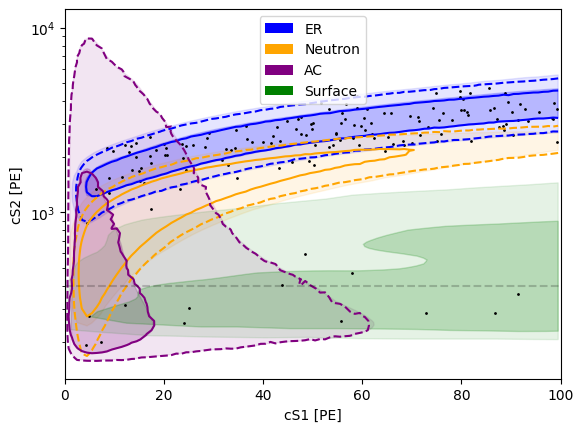

In [ ]:
plot_contours(
    xenonnt_sr0_st,
    {
        "experiment_name": "xenonnt_sr0",
        "specs": [
            {
                "type": "bkg",
                "bkg_name": "er",
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr0_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr0_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "bkg",
                "bkg_name": "neutron",
                "color": "orange",
                "two_sigma_contour_fname": "xenonnt_sr0_neutron_2sigma.csv",
                "log10_contour": False,
                "label": "Neutron",
            },
            {
                "type": "bkg",
                "bkg_name": "ac",
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr0_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr0_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
            {
                "type": "bkg",
                "plot_contour": False,
                "bkg_name": "surface",
                "color": "green",
                "one_sigma_contour_fname": "xenonnt_sr0_surface_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr0_surface_2sigma.csv",
                "log10_contour": False,
                "label": "Surface",
            },
        ],
    },
)

data = xenonnt_sr0_st.experiment_instances[0].get_data()
plt.yscale("log")
plt.scatter(data["cs1"], data["cs2"], s=1, c="k")
plt.xlim(0, 100)
plt.ylim(10**2.1, 10**4.1)

plt.axhline(400, color="k", linestyle="--", alpha=0.2)

plt.xlabel("cS1 [PE]")
plt.ylabel("cS2 [PE]")
plt.savefig("../plots/xenonnt_sr0_cs1_cs2_contours.png", dpi=600, bbox_inches="tight")

In [6]:
xenonnt_sr0_st.print_best_fit(200)

xenonnt_sr0
           Nominal   Best fit
er             134   135 ± 12
neutron  1.1 ± 0.5  1.1 ± 0.5
ac       4.3 ± 0.9  4.3 ± 0.8
surface     14 ± 3     12 ± 2
Signal best fit: 1.6886115837971176



Running inference: 100%|██████████| 90/90 [01:08<00:00,  1.31it/s]


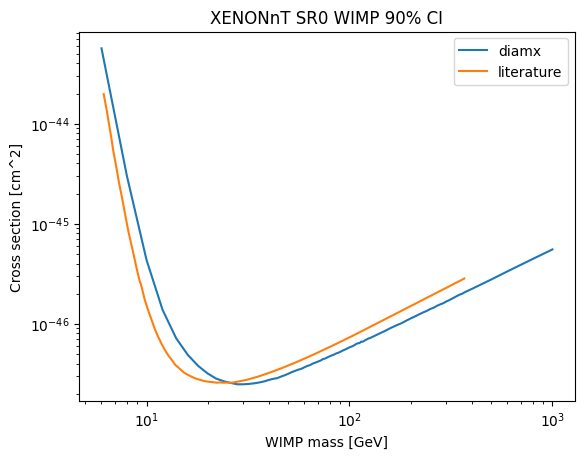

In [7]:
# Reproducing Fig. 4 (upper limit)
xenonnt_sr0_st.run_inference(output_file_name="xenonnt_sr0_wimp_ci_full_roi.csv")
ci = np.loadtxt("./diamx_output/xenonnt_sr0_wimp_ci_full_roi.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr0_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0 WIMP 90% CI")
plt.savefig("../plots/xenonnt_sr0_wimp_ci_full_roi.png", dpi=600)

Alternatively, use `cS2 > 400PE`:

Generating background templates for xenonnt_sr0: 100%|██████████| 4/4 [00:13<00:00,  3.36s/it]
Generating shaped background templates for xenonnt_sr0: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr0: 100%|██████████| 90/90 [10:46<00:00,  7.18s/it]


xenonnt_sr0
           Nominal   Best fit
er             134   134 ± 12
neutron  1.1 ± 0.5  1.1 ± 0.5
ac               1  0.0 ± 0.7
surface          1  3.0 ± 1.7
Signal best fit: 3.113224527025174



Running inference: 100%|██████████| 90/90 [01:33<00:00,  1.04s/it]


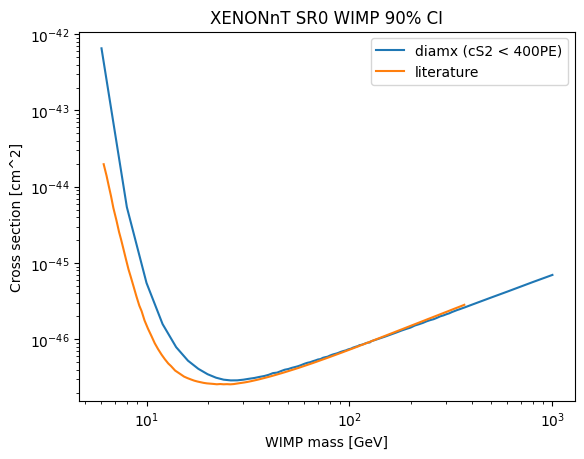

In [8]:
xenonnt_sr0_st_400PE = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_wimp_config.json"),
)
xenonnt_sr0_st_400PE.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr0_st_400PE.generate_templates()
xenonnt_sr0_st_400PE.print_best_fit(200)
xenonnt_sr0_st_400PE.run_inference(output_file_name="xenonnt_sr0_wimp_ci_400PE.csv")
ci_400PE = np.loadtxt("./diamx_output/xenonnt_sr0_wimp_ci_400PE.csv", delimiter=",")
plt.plot(ci_400PE[:, 0], ci_400PE[:, 2] * 1e-44, label="diamx (cS2 < 400PE)")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr0_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0 WIMP 90% CI")
plt.savefig("../plots/xenonnt_sr0_wimp_ci_400PE.png", dpi=600, bbox_inches="tight")

## 2. LZ WS2022

DOI: https://doi.org/10.1103/PhysRevLett.131.041002

Modelling: beta+gamma (flat ER), neutrino (flat ER), 127Xe (5.2keV L-shell with 0.87 Q_L/Q_beta), 124Xe (5.98keV + 10keV), 37Ar (2.82keV)

In [9]:
lz_ws2022_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "lz_ws2022_wimp_config.json"),
)
lz_ws2022_st.register_experiment(diamx.experiments.LZWS2022)
lz_ws2022_st.generate_templates()

/home/mhliu/anaconda3/envs/xenon_mc/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Generating background templates for lz_ws2022:   0%|          | 0/6 [00:00<?, ?it/s]

Generating background templates for lz_ws2022: 100%|██████████| 6/6 [05:26<00:00, 54.42s/it] /home/mhliu/anaconda3/envs/xenon_mc/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()

Generating shaped background templates for lz_ws2022: 0it [00:00, ?it/s]
Generating signal templates for lz_ws2022: 100%|██████████| 67/67 [36:42<00:00, 32.87s/it]


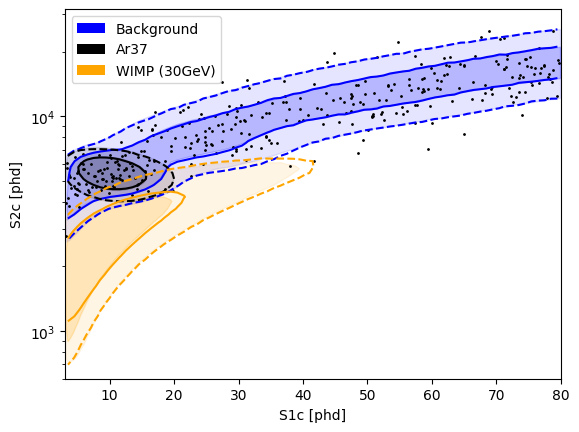

In [10]:
plot_contours(
    lz_ws2022_st,
    {
        "experiment_name": "lz_ws2022",
        "specs": [
            {
                "type": "best_fit_bkg",
                "bkg_to_include": None,
                "signal_parameter_value": 30,
                "color": "blue",
                "one_sigma_contour_fname": "lz_ws2022_bkg_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2022_bkg_2sigma.csv",
                "log10_contour": True,
                "label": "Background",
            },
            {
                "type": "bkg",
                "bkg_name": "ar37",
                "color": "k",
                "one_sigma_contour_fname": "lz_ws2022_ar37_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2022_ar37_2sigma.csv",
                "log10_contour": True,
                "label": "Ar37",
            },
            {
                "type": "signal",
                "signal_parameter_value": 30,
                "color": "orange",
                "one_sigma_contour_fname": "lz_ws2022_wimp_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2022_wimp_2sigma.csv",
                "log10_contour": True,
                "label": "WIMP (30GeV)",
            },
        ],
    },
)

# Scatter the data points
data = lz_ws2022_st.experiment_instances[0].get_data()
plt.yscale("log")
plt.scatter(data["s1c"], data["s2c"], s=1, c="k")

plt.xlabel("S1c [phd]")
plt.ylabel("S2c [phd]")
plt.xlim(3, 80)
plt.ylim(600, 10**4.5)

plt.savefig("../plots/lz_ws2022_s1c_s2c_contours.png", dpi=600, bbox_inches="tight")

In [11]:
lz_ws2022_st.print_best_fit(30, disable_rounding=True, stabilize_fit=False)

lz_ws2022
                           Nominal                                 Best fit
beta                  215.0 ± 36.0  224.46396439845762 ± 16.168874024476867
neutrino                27.1 ± 1.6  27.119061772197366 ± 1.5984858616972573
xe127                    9.2 ± 0.8   9.245741388546795 ± 0.7932706198055915
xe124     5.0 ± 1.3999999999999997   5.314546367178356 ± 1.3755565434540105
xe136                   15.1 ± 2.4   15.142167275185992 ± 2.389461916748272
ar37                          50.0    50.27325466028408 ± 9.081871293651606
Signal best fit: 5.835453178239078e-06



Running inference: 100%|██████████| 67/67 [01:11<00:00,  1.07s/it]


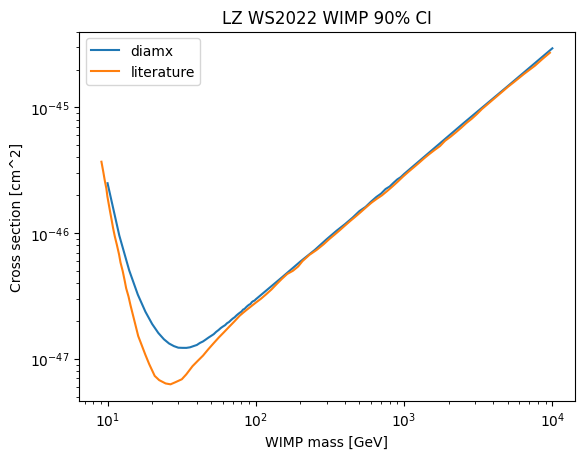

In [12]:
# Reproducing Fig. 5 (upper limit)
lz_ws2022_st.run_inference(output_file_name="lz_ws2022_wimp_ci.csv")
ci = np.loadtxt("./diamx_output/lz_ws2022_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/lz_ws2022_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("LZ WS2022 WIMP 90% CI")
plt.savefig("../plots/lz_ws2022_wimp_ci.png", dpi=600)
# plt.show()

## 3. XENONnT combined SR0 & SR1

arXiv:2502.18005

In [13]:
xenonnt_sr01_st = diamx.Context(
    os.path.join(
        diamx_dir, "..", "config", "xenonnt_sr0_and_1_wimp_config_full_roi.json"
    ),
)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR1a)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR1b)
xenonnt_sr01_st.generate_templates()

Generating background templates for xenonnt_sr0: 100%|██████████| 4/4 [00:07<00:00,  1.86s/it]
Generating shaped background templates for xenonnt_sr0: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr0: 100%|██████████| 90/90 [00:00<00:00, 2238.83it/s]
Generating background templates for xenonnt_sr1a:  60%|██████    | 3/5 [00:25<00:18,  9.30s/it]

S1ReconEffXENONnT_llh's map s1_recon_eff is using the parameter s1_recon_eff_sigma.
eff's map energy_eff is using the parameter xenonnt_eff_sigma.
Saving cut acceptance map.


Generating background templates for xenonnt_sr1a: 100%|██████████| 5/5 [00:36<00:00,  7.30s/it]
Generating shaped background templates for xenonnt_sr1a: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr1a: 100%|██████████| 90/90 [10:50<00:00,  7.23s/it]
Generating background templates for xenonnt_sr1b:  50%|█████     | 2/4 [00:16<00:16,  8.39s/it]

S1ReconEffXENONnT_llh's map s1_recon_eff is using the parameter s1_recon_eff_sigma.
eff's map energy_eff is using the parameter xenonnt_eff_sigma.
Saving cut acceptance map.


Generating background templates for xenonnt_sr1b: 100%|██████████| 4/4 [00:27<00:00,  6.81s/it]
Generating shaped background templates for xenonnt_sr1b: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr1b: 100%|██████████| 90/90 [11:03<00:00,  7.37s/it]


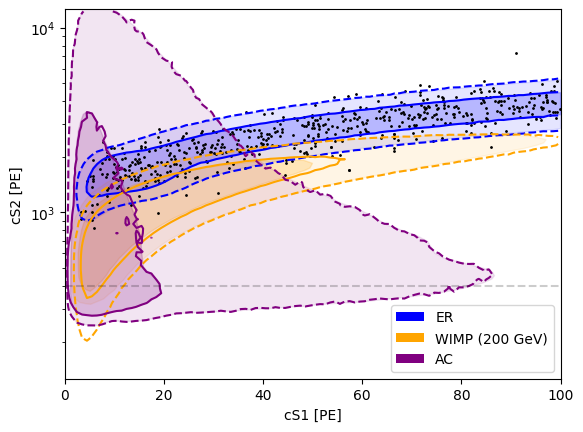

In [14]:
plot_contours(
    xenonnt_sr01_st,
    {
        "experiment_name": "xenonnt_sr1a",
        "specs": [
            {
                "type": "best_fit_bkg",
                "bkg_to_include": ["er_flat", "tritium", "ar37"],
                "signal_parameter_value": 200,
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr1a_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1a_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "signal",
                "signal_parameter_value": 200,
                "color": "orange",
                "one_sigma_contour_fname": "xenonnt_sr1b_wimp_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_wimp_2sigma.csv",
                "log10_contour": False,
                "label": "WIMP (200 GeV)",
            },
            {
                "type": "bkg",
                "bkg_name": "xenonnt_sr1_ac",
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr1b_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
        ],
    },
)
data = xenonnt_sr01_st.experiment_instances[1].get_data()
plt.yscale("log")
plt.scatter(data["cs1"], data["cs2"], s=1, c="k")
plt.xlim(0, 100)
plt.ylim(10**2.1, 10**4.1)

plt.axhline(400, color="k", linestyle="--", alpha=0.2)
plt.xlabel("cS1 [PE]")
plt.ylabel("cS2 [PE]")
plt.savefig("../plots/xenonnt_sr1a_cs1_cs2_contours.png", dpi=600, bbox_inches="tight")

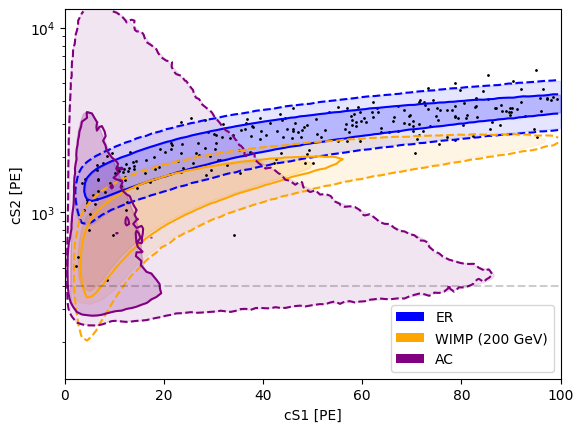

In [15]:
plot_contours(
    xenonnt_sr01_st,
    {
        "experiment_name": "xenonnt_sr1b",
        "specs": [
            {
                "type": "best_fit_bkg",
                "bkg_to_include": ["er_flat", "tritium"],
                "signal_parameter_value": 200,
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr1b_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "signal",
                "signal_parameter_value": 200,
                "color": "orange",
                "one_sigma_contour_fname": "xenonnt_sr1b_wimp_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_wimp_2sigma.csv",
                "log10_contour": False,
                "label": "WIMP (200 GeV)",
            },
            {
                "type": "bkg",
                "bkg_name": "xenonnt_sr1_ac",
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr1b_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
        ],
    },
)
data = xenonnt_sr01_st.experiment_instances[2].get_data()
plt.yscale("log")
plt.scatter(data["cs1"], data["cs2"], s=1, c="k")
plt.xlim(0, 100)
plt.ylim(10**2.1, 10**4.1)

plt.axhline(400, color="k", linestyle="--", alpha=0.2)
plt.xlabel("cS1 [PE]")
plt.ylabel("cS2 [PE]")
plt.savefig("../plots/xenonnt_sr1b_cs1_cs2_contours.png", dpi=600, bbox_inches="tight")

In [16]:
xenonnt_sr01_st.print_best_fit(200)

xenonnt_sr0
                   Nominal   Best fit
er                     134   135 ± 12
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
ac               4.3 ± 0.9  4.3 ± 0.8
surface             14 ± 3     12 ± 2
Signal best fit: 1.1672102359641965

xenonnt_sr1a
                     Nominal     Best fit
er_flat             430 ± 30     460 ± 30
tritium                   62      20 ± 30
ar37                  58 ± 6       53 ± 5
xenonnt_neutron  0.47 ± 0.19  0.47 ± 0.18
xenonnt_sr1_ac   2.12 ± 0.18  2.10 ± 0.18
Signal best fit: 0.7822156653556871

xenonnt_sr1b
                   Nominal   Best fit
er_flat           151 ± 11   156 ± 10
tritium                101    71 ± 17
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
xenonnt_sr1_ac   3.8 ± 0.3  3.8 ± 0.3
Signal best fit: 1.4082230972394427



Running inference: 100%|██████████| 90/90 [15:51<00:00, 10.58s/it]


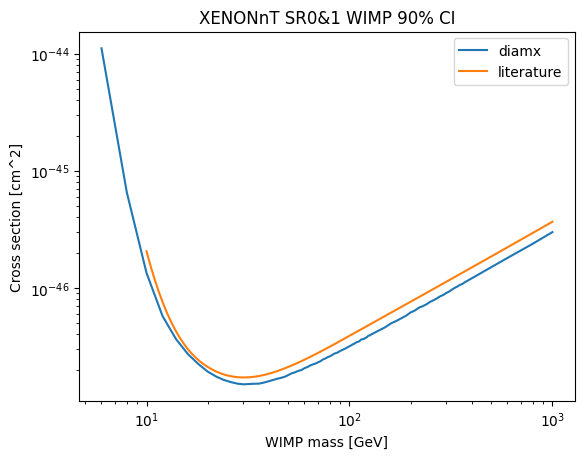

In [17]:
xenonnt_sr01_st.run_inference(output_file_name="xenonnt_sr1_wimp_ci_full_roi.csv")
ci = np.loadtxt("./diamx_output/xenonnt_sr1_wimp_ci_full_roi.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr1_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0&1 WIMP 90% CI")
plt.savefig("../plots/xenonnt_sr1_wimp_ci_full_roi.png", dpi=600)
# plt.show()

Generating background templates for xenonnt_sr0: 100%|██████████| 4/4 [00:07<00:00,  1.85s/it]
Generating shaped background templates for xenonnt_sr0: 0it [00:00, ?it/s]
Generating background templates for xenonnt_sr1a: 100%|██████████| 5/5 [00:31<00:00,  6.35s/it]
Generating shaped background templates for xenonnt_sr1a: 0it [00:00, ?it/s]
Generating background templates for xenonnt_sr1b: 100%|██████████| 4/4 [00:20<00:00,  5.19s/it]
Generating shaped background templates for xenonnt_sr1b: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr1b: 100%|██████████| 90/90 [11:03<00:00,  7.37s/it]


xenonnt_sr0
                   Nominal   Best fit
er                     134   135 ± 12
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
ac                       1  0.0 ± 0.7
surface                  1  3.0 ± 1.7
Signal best fit: 1.819508807465924

xenonnt_sr1a
                     Nominal     Best fit
er_flat             430 ± 30     460 ± 30
tritium                   62      20 ± 30
ar37                  58 ± 6       53 ± 5
xenonnt_neutron  0.47 ± 0.19  0.47 ± 0.19
xenonnt_sr1_ac   2.12 ± 0.18  2.11 ± 0.18
Signal best fit: 1.2193589882946738

xenonnt_sr1b
                   Nominal   Best fit
er_flat           151 ± 11   156 ± 10
tritium                101    70 ± 17
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
xenonnt_sr1_ac   3.8 ± 0.3  3.8 ± 0.3
Signal best fit: 2.1952123528007723



Running inference: 100%|██████████| 90/90 [16:38<00:00, 11.10s/it]


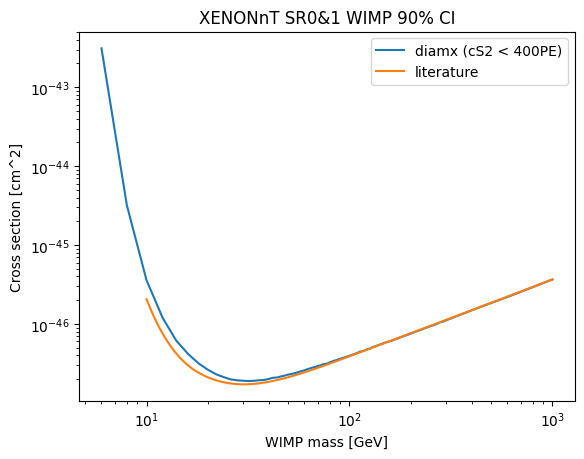

In [18]:
xenonnt_sr01_st_400PE = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_and_1_wimp_config.json"),
)
xenonnt_sr01_st_400PE.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr01_st_400PE.register_experiment(diamx.experiments.XENONnTSR1a)
xenonnt_sr01_st_400PE.register_experiment(diamx.experiments.XENONnTSR1b)
xenonnt_sr01_st_400PE.generate_templates()
xenonnt_sr01_st_400PE.print_best_fit(200)
xenonnt_sr01_st_400PE.run_inference(output_file_name="xenonnt_sr1_wimp_ci_400PE.csv")
ci_400PE = np.loadtxt("./diamx_output/xenonnt_sr1_wimp_ci_400PE.csv", delimiter=",")
plt.plot(ci_400PE[:, 0], ci_400PE[:, 2] * 1e-44, label="diamx (cS2 < 400PE)")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr1_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0&1 WIMP 90% CI")

plt.savefig("../plots/xenonnt_sr1_wimp_ci_400PE.png", dpi=600, bbox_inches="tight")

## 4. LZ WS2024

arXiv:2410.17036

In [19]:
lz_ws2024_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "lz_ws2024_wimp_config.json"),
)
lz_ws2024_st.register_experiment(diamx.experiments.LZWS2022)
lz_ws2024_st.register_experiment(diamx.experiments.LZWS2024)
lz_ws2024_st.generate_templates()

/home/mhliu/anaconda3/envs/xenon_mc/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Generating background templates for lz_ws2022: 100%|██████████| 6/6 [00:00<00:00, 2291.97it/s]/home/mhliu/anaconda3/envs/xenon_mc/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()



Generating shaped background templates for lz_ws2022: 0it [00:00, ?it/s]
Generating background templates for lz_ws2024: 100%|██████████| 8/8 [07:37<00:00, 57.24s/it] 
Generating shaped background templates for lz_ws2024: 100%|██████████| 12/12 [06:22<00:00, 31.84s/it]
Generating signal templates for lz_ws2024:  13%|█▎        | 9/67 [03:50<29:28, 30.50s/it]WARNING: your position resolution is worse than 10 cm. Is that correct?!
Setting resolution to perfect, for the current event.
Generating signal templates for lz_ws2024: 100%|██████████| 67/67 [36:15<00:00, 32.47s/it]


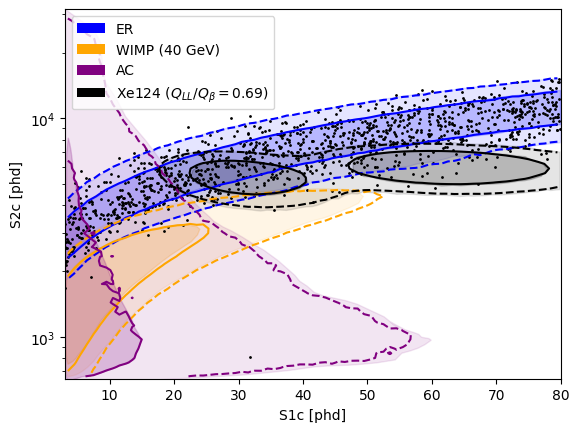

In [20]:
plot_contours(
    lz_ws2024_st,
    {
        "experiment_name": "lz_ws2024",
        "specs": [
            {
                "type": "best_fit_bkg",
                "signal_parameter_value": 40,
                "bkg_to_include": [
                    "pb214",
                    "kr85_ar39_detgamma",
                    "solar_neutrino_er",
                    "pb212_po218",
                    "tritium_c14",
                    "xe136",
                    "xe127_xe125",
                    "xe124",
                ],
                "color": "blue",
                "one_sigma_contour_fname": "lz_ws2024_er_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2024_er_2sigma.csv",
                "log10_contour": True,
                "label": "ER",
            },
            {
                "type": "signal",
                "signal_parameter_value": 40,
                "color": "orange",
                "one_sigma_contour_fname": "lz_ws2024_wimp_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2024_wimp_2sigma.csv",
                "log10_contour": True,
                "label": "WIMP (40 GeV)",
            },
            {
                "type": "bkg",
                "bkg_name": "ac",
                "color": "purple",
                "one_sigma_contour_fname": "lz_ws2024_ac_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2024_ac_2sigma.csv",
                "log10_contour": True,
                "label": "AC",
            },
            {
                "type": "shaped_bkg",
                "bkg_name": "xe124",
                "color": "k",
                "shape_parameter_value": 69,
                "one_sigma_contour_fname": [
                    "lz_ws2024_xe124_1sigma_left.csv",
                    "lz_ws2024_xe124_1sigma_right.csv",
                ],
                "two_sigma_contour_fname": "lz_ws2024_xe124_2sigma.csv",
                "log10_contour": True,
                "label": r"Xe124 ($Q_{LL}/Q_{\beta}=0.69$)",
            },
        ],
    },
)
data = lz_ws2024_st.experiment_instances[1].get_data()
plt.yscale("log")
plt.xlim(3, 80)
plt.ylim(645, 10**4.5)
plt.scatter(data["s1c"], data["s2c"], s=1, c="k")
plt.xlabel("S1c [phd]")
plt.ylabel("S2c [phd]")
plt.savefig("../plots/lz_ws2024_s1c_s2c_contours.png", dpi=600, bbox_inches="tight")

In [21]:
lz_ws2024_st.print_best_fit(40, disable_rounding=True, stabilize_fit=False)

lz_ws2022
                           Nominal                                Best fit
beta                  215.0 ± 36.0  224.4820769486279 ± 16.166459574249096
neutrino                27.1 ± 1.6  27.118088915733587 ± 1.598472271692544
xe127                    9.2 ± 0.8  9.245482499040357 ± 0.7932713386712608
xe124     5.0 ± 1.3999999999999997  5.313250637931055 ± 1.3755772814875216
xe136                   15.1 ± 2.4    15.13940536087391 ± 2.38943440871272
ar37                          50.0   50.25557457262034 ± 9.079458393271777
Signal best fit: 1.0438637239888257e-06

lz_ws2024
                                    Nominal  \
pb214                          743.0 ± 88.0   
kr85_ar39_detgamma             162.0 ± 22.0   
solar_neutrino_er               102.0 ± 6.0   
pb212_po218                      62.7 ± 7.5   
tritium_c14         58.29999999999999 ± 3.3   
xe136                            55.6 ± 8.3   
xe127_xe125                       3.2 ± 0.6   
ac                                2.8 

Running inference: 100%|██████████| 67/67 [13:57<00:00, 12.50s/it]


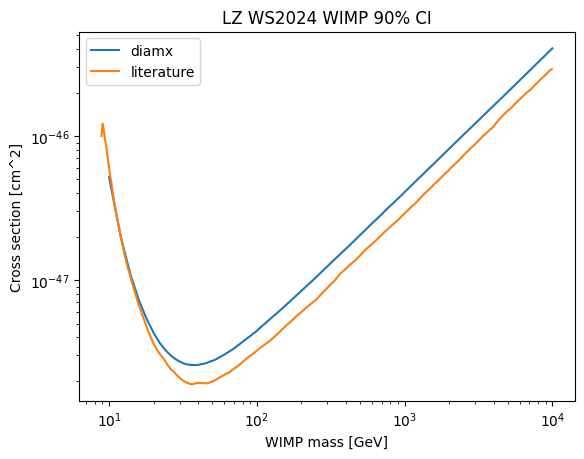

In [22]:
lz_ws2024_st.run_inference(output_file_name="lz_ws2024_wimp_ci.csv")
ci = np.loadtxt("./diamx_output/lz_ws2024_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/lz_ws2024_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("LZ WS2024 WIMP 90% CI")
plt.savefig("../plots/lz_ws2024_wimp_ci.png", dpi=600)
# plt.show()